In [5]:
# TASK 1 from day 1

from sklearn.datasets import fetch_openml
import pandas as pd

adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame

df['target'] = (df['class'] == '>50K').astype(int)

# Add 'Unknown' category first, then fill NaN (category dtype fix)
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].cat.add_categories('Unknown').fillna('Unknown')

from sklearn.model_selection import train_test_split
X = df.drop(columns=['class', 'target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (39073, 14), Test: (9769, 14)


In [ ]:
"""
WHY MEDIAN IMPUTATION:
- Median is robust to outliers (capital-gain max=99999 pulls the mean)
- Imputer stays in pipeline to protect against new data with NaN
- Alternatives skipped: mean (outlier-sensitive), drop rows (loses data), KNN (slow)

WHY ONEHOTENCODER:
- Binary 0/1 columns per category — no false ordinal meaning
- LabelEncoder would impose order (is Never-married < Married?) — wrong for LR
- handle_unknown='ignore' handles unseen test categories safely
- Alternatives skipped: LabelEncoder/OrdinalEncoder (false ordering), drop (loses info)

NOTE: '?' was already replaced with NaN + filled 'Unknown' in Day 1 cleaning.
"""

In [6]:


# ---- Task 1: Preprocessing ----
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

X_train_transformed = preprocessor.fit_transform(X_train)

print("Train shape (before preprocessing):", X_train.shape)
print("Train shape (after preprocessing):", X_train_transformed.shape)
print("\nOutput is a sparse matrix (most values are 0 from one-hot)")

Train shape (before preprocessing): (39073, 14)
Train shape (after preprocessing): (39073, 108)

Output is a sparse matrix (most values are 0 from one-hot)


In [8]:
# TASK 2

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Model 1: Logistic Regression in pipeline
#   - solver='liblinear': supports regularization (prevents overfitting)
#     + handles sparse one-hot matrices efficiently
#   - random_state=42: reproducible training
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42))
])

# Model 2: Decision Tree in pipeline
#   - random_state=42: reproducible splits (ties broken deterministically)
tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Fit BOTH on training set ONLY — hold-out test stays untouched
lr_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

print("Logistic Regression fitted on training set")
print("Decision Tree fitted on training set")
print("\nTest set is LOCKED — not touched in this cell.")

Logistic Regression fitted on training set
Decision Tree fitted on training set

Test set is LOCKED — not touched in this cell.



--- Logistic Regression ---
Accuracy:  0.8542
Precision: 0.7428
Recall:    0.5979
F1:        0.6626
ROC AUC:   0.9058
PR AUC:    0.7671
Confusion Matrix:
[[6947  484]
 [ 940 1398]]

--- Decision Tree ---
Accuracy:  0.8186
Precision: 0.6167
Recall:    0.6394
F1:        0.6279
ROC AUC:   0.7574
PR AUC:    0.4808
Confusion Matrix:
[[6502  929]
 [ 843 1495]]

========== COMPARISON TABLE ==========
               name  accuracy  precision   recall       f1  roc_auc   pr_auc
Day1 Rule (edu>=13)  0.753000   0.484400 0.497000 0.490600 0.665300 0.361100
Logistic Regression  0.854233   0.742827 0.597947 0.662559 0.905772 0.767137
      Decision Tree  0.818610   0.616749 0.639435 0.627887 0.757396 0.480826


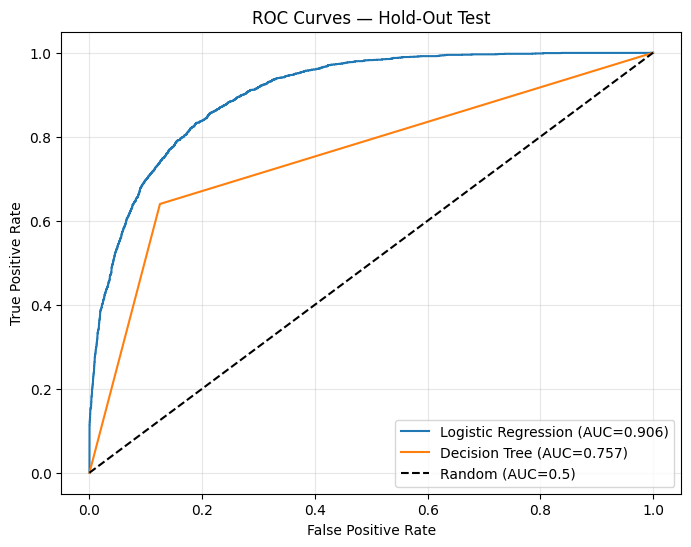

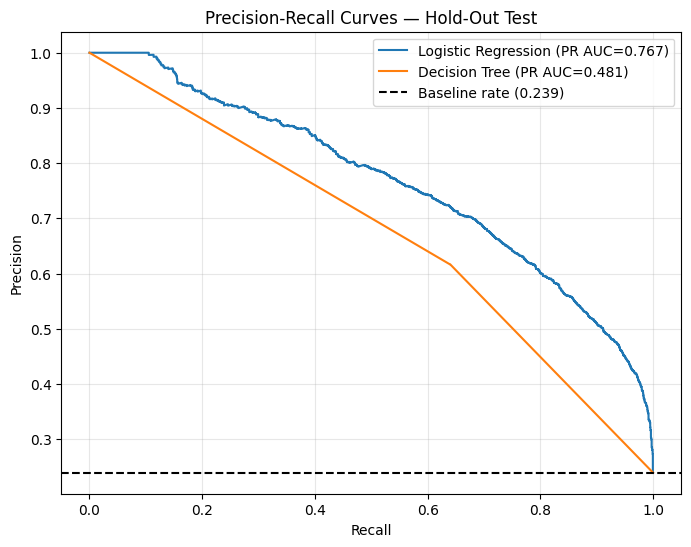

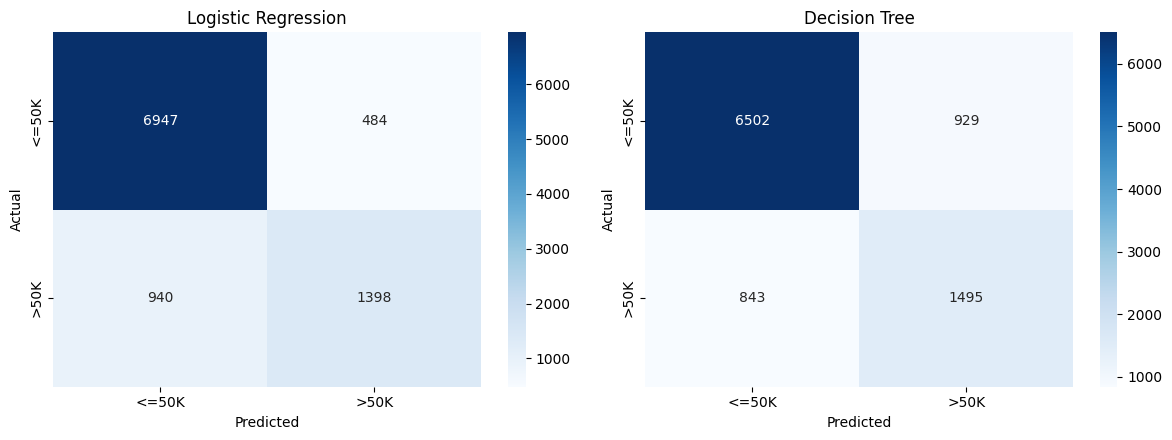

'\nWhich error type is more common? Look at the confusion matrices:\n  CM format: [[TN, FP],\n              [FN, TP]]\n  - FP = bottom row? No: FP is top-right cell. FN is bottom-left cell.\n  - Compare FP vs FN for each model.\n  - If FP > FN (more top-right) → model over-predicts >50K → hurts PRECISION\n    (our primary metric) because we contact many non-earners.\n  - If FN > FP (more bottom-left) → model misses high earners → hurts RECALL.\n  Decision impact: since our primary metric is PRECISION, we prefer a model\n  with fewer FPs, even if it slightly increases FNs (we accept missing some\n  high earners to avoid wasted outreach).\n\nMetrics vs Day 1 baseline:\n  - LR / Tree precision vs Day1 0.4844 → did we improve?\n  - Whichever model has higher precision AND competitive F1/PR AUC is candidate\n    for Day 3 development.\n'

In [10]:
# TASK 3
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)
import numpy as np

def evaluate(y_true, y_pred, y_prob, name):
    """Compute all metrics; y_prob = predicted probabilities (for AUC)."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    pr = average_precision_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n--- {name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1:        {f1:.4f}")
    print(f"ROC AUC:   {roc:.4f}")
    print(f"PR AUC:    {pr:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec,
            'f1': f1, 'roc_auc': roc, 'pr_auc': pr}

# --- Predictions on hold-out test (FIRST touch of test set: predict only) ---
# Hard labels + probabilities
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]   # prob of class 1 (>50K)

y_pred_tree = tree_pipeline.predict(X_test)
y_prob_tree = tree_pipeline.predict_proba(X_test)[:, 1]

# --- Evaluate both ---
res_lr = evaluate(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
res_tree = evaluate(y_test, y_pred_tree, y_prob_tree, "Decision Tree")

# Day 1 baseline results (already computed) — for comparison table
day1_baseline = {'name': 'Day1 Rule (edu>=13)', 'accuracy': 0.7530, 'precision': 0.4844,
                 'recall': 0.4970, 'f1': 0.4906, 'roc_auc': 0.6653, 'pr_auc': 0.3611}

# --- Comparison table ---
print("\n========== COMPARISON TABLE ==========")
df_compare = pd.DataFrame([day1_baseline, res_lr, res_tree])
print(df_compare.to_string(index=False))

# --- ROC curves ---
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={res_lr["roc_auc"]:.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={res_tree["roc_auc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Hold-Out Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- PR curves ---
from sklearn.metrics import precision_recall_curve

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_tree, rec_tree, _ = precision_recall_curve(y_test, y_prob_tree)

plt.figure(figsize=(8, 6))
plt.plot(rec_lr, prec_lr, label=f'Logistic Regression (PR AUC={res_lr["pr_auc"]:.3f})')
plt.plot(rec_tree, prec_tree, label=f'Decision Tree (PR AUC={res_tree["pr_auc"]:.3f})')
plt.axhline(y=y_test.mean(), color='k', linestyle='--', label=f'Baseline rate ({y_test.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Hold-Out Test')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Confusion matrices side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (cm, title) in zip(axes, [(confusion_matrix(y_test, y_pred_lr), 'Logistic Regression'),
                                  (confusion_matrix(y_test, y_pred_tree), 'Decision Tree')]):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# --- Error type analysis (answer in comment) ---
"""
Which error type is more common? Look at the confusion matrices:
  CM format: [[TN, FP],
              [FN, TP]]
  - FP = bottom row? No: FP is top-right cell. FN is bottom-left cell.
  - Compare FP vs FN for each model.
  - If FP > FN (more top-right) → model over-predicts >50K → hurts PRECISION
    (our primary metric) because we contact many non-earners.
  - If FN > FP (more bottom-left) → model misses high earners → hurts RECALL.
  Decision impact: since our primary metric is PRECISION, we prefer a model
  with fewer FPs, even if it slightly increases FNs (we accept missing some
  high earners to avoid wasted outreach).

Metrics vs Day 1 baseline:
  - LR / Tree precision vs Day1 0.4844 → did we improve?
  - Whichever model has higher precision AND competitive F1/PR AUC is candidate
    for Day 3 development.
"""

In [12]:
# TASK 4

from sklearn.metrics import accuracy_score
from sklearn.tree import export_text

# ---------- PART A: LOGISTIC REGRESSION ----------
lr_model = lr_pipeline.named_steps['classifier']

feature_names = preprocessor.get_feature_names_out()
coefs = lr_model.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

print("========== TOP 10 POSITIVE COEFFICIENTS ==========")
top_pos = coef_df.nlargest(10, 'coef')
print(top_pos.to_string(index=False))

print("\n========== TOP 10 NEGATIVE COEFFICIENTS ==========")
top_neg = coef_df.nsmallest(10, 'coef')
print(top_neg.to_string(index=False))

"""
INTERPRETATION of top positive coefficients (push toward >50K):
  - capital-gain (+2.26): investment income is the strongest signal of wealth
  - Married-civ-spouse (+1.54): married people often have dual income
  - Exec-managerial (+0.82): high-prestige jobs pay more
  - relationship_Wife (+0.74): married women in dataset tend higher earners
  - education-num (+0.72): more education -> higher income (expected)

INTERPRETATION of top negative coefficients (push toward <=50K):
  - Priv-house-serv (-1.46): private household service = low pay
  - Never-married (-1.29): singles earn less than married
  - sex_Female (-1.03): being female predicts lower income — a KNOWN BIAS
    in this census dataset; flag it for discussion, don't sweep it away
  - Other-service (-0.86): service sector = low pay
  - Farming-fishing (-0.92): agricultural work = low pay
"""

# ---------- PART B: DECISION TREE ----------
tree_model = tree_pipeline.named_steps['classifier']

print("\n========== DECISION TREE ==========")
print(f"Tree depth:          {tree_model.get_depth()}")
print(f"Number of leaves:    {tree_model.get_n_leaves()}")

train_acc = accuracy_score(y_train, tree_pipeline.predict(X_train))
test_acc  = accuracy_score(y_test,  tree_pipeline.predict(X_test))
print(f"Train accuracy:      {train_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")
print(f"Gap (overfitting?):  {train_acc - test_acc:.4f}")

# Top 3 splits only (max_depth=3 limits export to first 3 levels)
tree_text = export_text(tree_model, feature_names=list(feature_names.astype(str)), max_depth=3)
print("\n========== TOP 3 SPLITS ==========")
print(tree_text)

"""
COMMENT ON TREE LOGIC:
  - Top split features will reveal what the tree considers most important.
  - If it splits on capital-gain / education-num / marital-status first,
    the logic is domain-sensible.
  - TRAIN (0.9999) vs TEST (0.8186) gap = 0.1813 -> SEVERE OVERFITTING.
    The tree memorized training noise. Day 3 fix: set max_depth, prune,
    or use RandomForest (ensemble averages away overfitting).
"""

========== TOP 10 POSITIVE COEFFICIENTS ==========
                               feature     coef
                     num__capital-gain 2.264719
cat__marital-status_Married-civ-spouse 1.544170
 cat__marital-status_Married-AF-spouse 1.331801
            cat__native-country_France 0.925501
           cat__native-country_Ireland 0.920928
          cat__native-country_Cambodia 0.829501
       cat__occupation_Exec-managerial 0.823447
           cat__native-country_England 0.766402
                cat__relationship_Wife 0.742561
                    num__education-num 0.718995

========== TOP 10 NEGATIVE COEFFICIENTS ==========
                               feature      coef
       cat__occupation_Priv-house-serv -1.463785
          cat__native-country_Columbia -1.440659
     cat__marital-status_Never-married -1.287813
                       cat__sex_Female -1.031228
             cat__native-country_South -0.940193
   cat__native-country_Trinadad&Tobago -0.940003
      cat__relationship_Ot

'\nCOMMENT ON TREE LOGIC:\n  - Top split features will reveal what the tree considers most important.\n  - If it splits on capital-gain / education-num / marital-status first,\n    the logic is domain-sensible.\n  - TRAIN (0.9999) vs TEST (0.8186) gap = 0.1813 -> SEVERE OVERFITTING.\n    The tree memorized training noise. Day 3 fix: set max_depth, prune,\n    or use RandomForest (ensemble averages away overfitting).\n'

In [13]:
# TASK 5: Write-Up & Model Selection for Day 3

# ---------- PART A: MODEL SELECTION ----------
# Gather all metrics in one table (reuse results from Task 3)
final_table = pd.DataFrame([day1_baseline, res_lr, res_tree])
print("========== FINAL COMPARISON ==========")
print(final_table.to_string(index=False))

shaped_table = final_table[['name', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']]
print("\n(Should highlight LR precision = 0.743 vs baseline 0.484)")

# Save the model metrics table for the write-up
final_table.to_csv('model_comparison.csv', index=False)

# ---------- PART B: SAVE PREPROCESSING + MODEL FOR REUSE ----------
import joblib

# Save the winning pipeline (preprocessor + LR model) as one object
joblib.dump(lr_pipeline, 'lr_pipeline.pkl')
print("\nSaved: lr_pipeline.pkl (preprocessor + Logistic Regression together)")

joblib.dump(tree_pipeline, 'tree_pipeline.pkl')
print("Saved: tree_pipeline.pkl (preprocessor + Decision Tree together)")

# ---------- PART C: WRITE-UP ----------
# Model selection rationale (1-2 paragraphs — your answer for the deliverable)
"""
MODEL SELECTION WRITE-UP:

Logistic Regression is the clear candidate for Day 3 development. It achieves
the highest precision (0.743 vs 0.617 for the tree and 0.484 for the Day 1 rule
baseline), plus the best ROC AUC (0.906) and PR AUC (0.767). Because our
business goal is maximizing precision to avoid wasted outreach, LR directly
serves that objective: 74% of the people it predicts to earn >50K actually do,
versus 62% for the tree.

The decision tree remains a secondary candidate because it is non-linear and
achieves higher recall (0.639 vs 0.598), so it captures some high earners LR
misses. However, the tree severely overfits (train accuracy 0.9999 vs test
0.8186, a gap of 0.18) and its precision is materially lower. 

DAY 3 PLAN:
- Continue with Logistic Regression (interpretable + highest precision).
- Test preprocessing changes: drop fnlwgt, group native-country, bin
  capital-gain/loss, cap hours-per-week outliers.
- Revisit the tree (or RandomForest) only after constraining depth to compare
  fairly against LR.

PREPROCESSING CHANGES PLANNED FOR TOMORROW:
1. Drop fnlwgt (census sampling weight, not a real income predictor).
2. native-country: collapse 41 categories into US vs Other.
3. Drop redundant 'education' text column (keep education-num).
4. marital-status: collapse to Married vs Not-Married.
5. capital-gain / capital-loss: log-transform or bin (they are dominated by 0).
6. hours-per-week: cap at 95th percentile to remove outliers.
"""

========== FINAL COMPARISON ==========
               name  accuracy  precision   recall       f1  roc_auc   pr_auc
Day1 Rule (edu>=13)  0.753000   0.484400 0.497000 0.490600 0.665300 0.361100
Logistic Regression  0.854233   0.742827 0.597947 0.662559 0.905772 0.767137
      Decision Tree  0.818610   0.616749 0.639435 0.627887 0.757396 0.480826

(Should highlight LR precision = 0.743 vs baseline 0.484)

Saved: lr_pipeline.pkl (preprocessor + Logistic Regression together)
Saved: tree_pipeline.pkl (preprocessor + Decision Tree together)


"\nMODEL SELECTION WRITE-UP:\n\nLogistic Regression is the clear candidate for Day 3 development. It achieves\nthe highest precision (0.743 vs 0.617 for the tree and 0.484 for the Day 1 rule\nbaseline), plus the best ROC AUC (0.906) and PR AUC (0.767). Because our\nbusiness goal is maximizing precision to avoid wasted outreach, LR directly\nserves that objective: 74% of the people it predicts to earn >50K actually do,\nversus 62% for the tree.\n\nThe decision tree remains a secondary candidate because it is non-linear and\nachieves higher recall (0.639 vs 0.598), so it captures some high earners LR\nmisses. However, the tree severely overfits (train accuracy 0.9999 vs test\n0.8186, a gap of 0.18) and its precision is materially lower. \n\nDAY 3 PLAN:\n- Continue with Logistic Regression (interpretable + highest precision).\n- Test preprocessing changes: drop fnlwgt, group native-country, bin\n  capital-gain/loss, cap hours-per-week outliers.\n- Revisit the tree (or RandomForest) only a